# Uncertainty Quantification in Language Models

**Track 2 — analysis notebook**

This notebook is generated by `scripts/build_notebook.py` and calls the same functions the command-line scripts do, so it cannot drift from the source modules.

Run `scripts/run_experiment.py` first to produce the records this reads.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.analysis import analyse_task, top_signals
from src.config import FIGURES_DIR, TASKS
from src.experiment import records_for_task, signal_columns
from src.signals import SIGNAL_REGISTRY, get_spec

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

## 1. What a single example looks like

Each record carries the greedy generation, the sampled generations, every uncertainty signal, and the wall-clock cost of each generation pass.

In [2]:
records = records_for_task('gsm8k')
example = records[0]

print('Question:', example['question'][:200])
print()
print('Greedy answer:', example['greedy_canonical'], '| correct:', example['greedy_correct'])
print('Majority answer:', example['majority_answer'], '| correct:', example['majority_correct'])
print()
print('Distinct sampled answers:', sorted(set(example['sample_canonical'])))
print()
print('Timings (s):', {k: round(v, 2) for k, v in example['timings'].items()})

Question: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.

Greedy answer: 109 | correct: True
Majority answer: 109 | correct: True

Distinct sampled answers: ['10', '109', '18', '20', '39', '69.7', '99']

Timings (s): {'greedy_seconds': 9.41, 'sampling_seconds': 11.84, 'clustering_seconds': 0.12, 'verbalized_seconds': 0.2}


In [3]:
signal_view = pd.DataFrame(
    [
        {
            'signal': name,
            'value': example['signals'][name],
            'granularity': get_spec(name).granularity,
            'cost': get_spec(name).cost_tier,
        }
        for name in example['signals']
    ]
)
signal_view.sort_values(['granularity', 'signal']).reset_index(drop=True)

,signal,value,granularity,cost
0,lexical_entropy,1.748067e+00,sentence,multi_sample
1,num_distinct_answers,7.000000e+00,sentence,multi_sample
2,num_semantic_clusters,7.000000e+00,sentence,multi_sample
3,self_consistency,4.000000e-01,sentence,multi_sample
4,semantic_entropy,1.748067e+00,sentence,multi_sample
5,semantic_self_consistency,4.000000e-01,sentence,multi_sample
6,verbalized_confidence,1.000000e+00,sentence,extra_call
7,weighted_semantic_entropy,1.572583e+00,sentence,multi_sample
8,answer_log_perplexity,NaN,token,single_pass
9,answer_max_entropy,NaN,token,single_pass


## 2. Do the signals separate right from wrong answers?

The mechanism every downstream metric depends on: a useful signal must take systematically different values on correct and incorrect answers.

In [4]:
rows = []
for task in TASKS:
    task_records = records_for_task(task)
    columns = signal_columns(task_records)
    correct = np.array([r['greedy_correct'] for r in task_records])
    for name in ['mean_entropy', 'log_perplexity', 'semantic_entropy', 'self_consistency']:
        values = columns[name]
        finite = np.isfinite(values)
        rows.append({
            'task': task,
            'signal': name,
            'mean_when_correct': np.nanmean(values[finite & correct]),
            'mean_when_wrong': np.nanmean(values[finite & ~correct]),
        })

separation = pd.DataFrame(rows)
separation['gap'] = separation['mean_when_wrong'] - separation['mean_when_correct']
separation

,task,signal,mean_when_correct,mean_when_wrong,gap
0,nq_open,mean_entropy,0.529112,1.339463,0.810351
1,nq_open,log_perplexity,0.166765,0.612058,0.445293
2,nq_open,semantic_entropy,0.588274,1.655171,1.066897
3,nq_open,self_consistency,0.752632,0.304420,-0.448212
4,gsm8k,mean_entropy,0.215875,0.292789,0.076914
5,gsm8k,log_perplexity,0.159672,0.214846,0.055175
6,gsm8k,semantic_entropy,0.900023,1.561055,0.661032
7,gsm8k,self_consistency,0.670690,0.335714,-0.334975


## 3. Ranked estimator comparison

AUROC treats an incorrect answer as the positive class and the uncertainty score as the ranker. Bootstrap intervals are the point of this table: where they overlap, the ordering is not resolved.

In [5]:
analyses = {task: analyse_task(task) for task in TASKS}

for task, analysis in analyses.items():
    print(f'=== {task} | greedy accuracy {analysis.greedy_accuracy:.3f} '
          f'| {analysis.num_test} held-out examples ===')
    table = pd.DataFrame([
        {
            'signal': ev.display_name,
            'cost': ev.cost_tier,
            'AUROC': round(ev.auroc.value, 3),
            'CI low': round(ev.auroc.lower, 3),
            'CI high': round(ev.auroc.upper, 3),
            'AURC': round(ev.aurc.value, 3),
            'ECE': round(ev.ece_equal_mass, 3),
        }
        for ev in analysis.evaluations[:10]
    ])
    display(table)
    print()

=== nq_open | greedy accuracy 0.140 | 100 held-out examples ===


,signal,cost,AUROC,CI low,CI high,AURC,ECE
0,Sequence log-prob,single_pass,0.945,0.899,0.981,0.650,0.107
1,Sequence probability,single_pass,0.945,0.899,0.981,0.650,0.145
2,Lexical entropy,multi_sample,0.916,0.848,0.968,0.686,0.104
3,Self-consistency,multi_sample,0.914,0.842,0.966,0.686,0.130
4,Distinct answer strings,multi_sample,0.914,0.846,0.965,0.686,0.095
5,Log-perplexity,single_pass,0.914,0.855,0.964,0.678,0.134
6,Min max-softmax,single_pass,0.914,0.849,0.962,0.672,0.138
7,Distinct meanings,multi_sample,0.907,0.841,0.958,0.698,0.100
8,Semantic entropy (likelihood-weighted),multi_sample,0.907,0.845,0.957,0.704,0.109
9,Semantic entropy,multi_sample,0.900,0.826,0.956,0.701,0.114



=== gsm8k | greedy accuracy 0.560 | 50 held-out examples ===


,signal,cost,AUROC,CI low,CI high,AURC,ECE
0,Lexical entropy,multi_sample,0.884,0.780,0.966,0.176,0.155
1,Self-consistency,multi_sample,0.884,0.789,0.965,0.172,0.186
2,Distinct answer strings,multi_sample,0.874,0.770,0.961,0.178,0.134
3,Sequence log-prob,single_pass,0.828,0.684,0.945,0.240,0.104
4,Sequence probability,single_pass,0.828,0.684,0.945,0.240,0.040
5,Semantic entropy (likelihood-weighted),multi_sample,0.806,0.674,0.926,0.281,0.181
6,Semantic self-consistency,multi_sample,0.800,0.661,0.918,0.281,0.149
7,Semantic entropy,multi_sample,0.794,0.659,0.911,0.287,0.181
8,Distinct meanings,multi_sample,0.778,0.638,0.901,0.291,0.140
9,Log-perplexity,single_pass,0.745,0.592,0.884,0.299,0.198


## 4. Does semantic clustering beat plain string matching?

The targeted ablation. Semantic entropy and lexical entropy differ *only* in whether answers are grouped by meaning or by exact string, so the gap between them is what NLI clustering buys.

In [6]:
comparison = []
for task, analysis in analyses.items():
    by_name = {ev.signal: ev for ev in analysis.evaluations}
    for name in ['semantic_entropy', 'weighted_semantic_entropy', 'lexical_entropy']:
        if name in by_name:
            comparison.append({
                'task': task,
                'method': by_name[name].display_name,
                'AUROC': round(by_name[name].auroc.value, 3),
            })

pd.DataFrame(comparison).pivot(index='method', columns='task', values='AUROC')

task,gsm8k,nq_open
method,,
Lexical entropy,0.884,0.916
Semantic entropy,0.794,0.900
Semantic entropy (likelihood-weighted),0.806,0.907


## 5. Calibration

A raw entropy is not a probability, so each signal is mapped to P(correct) by a logistic calibrator **fitted on the dev split** and evaluated on the held-out split. Fitting on the reported split would make every method look far better calibrated than it is.

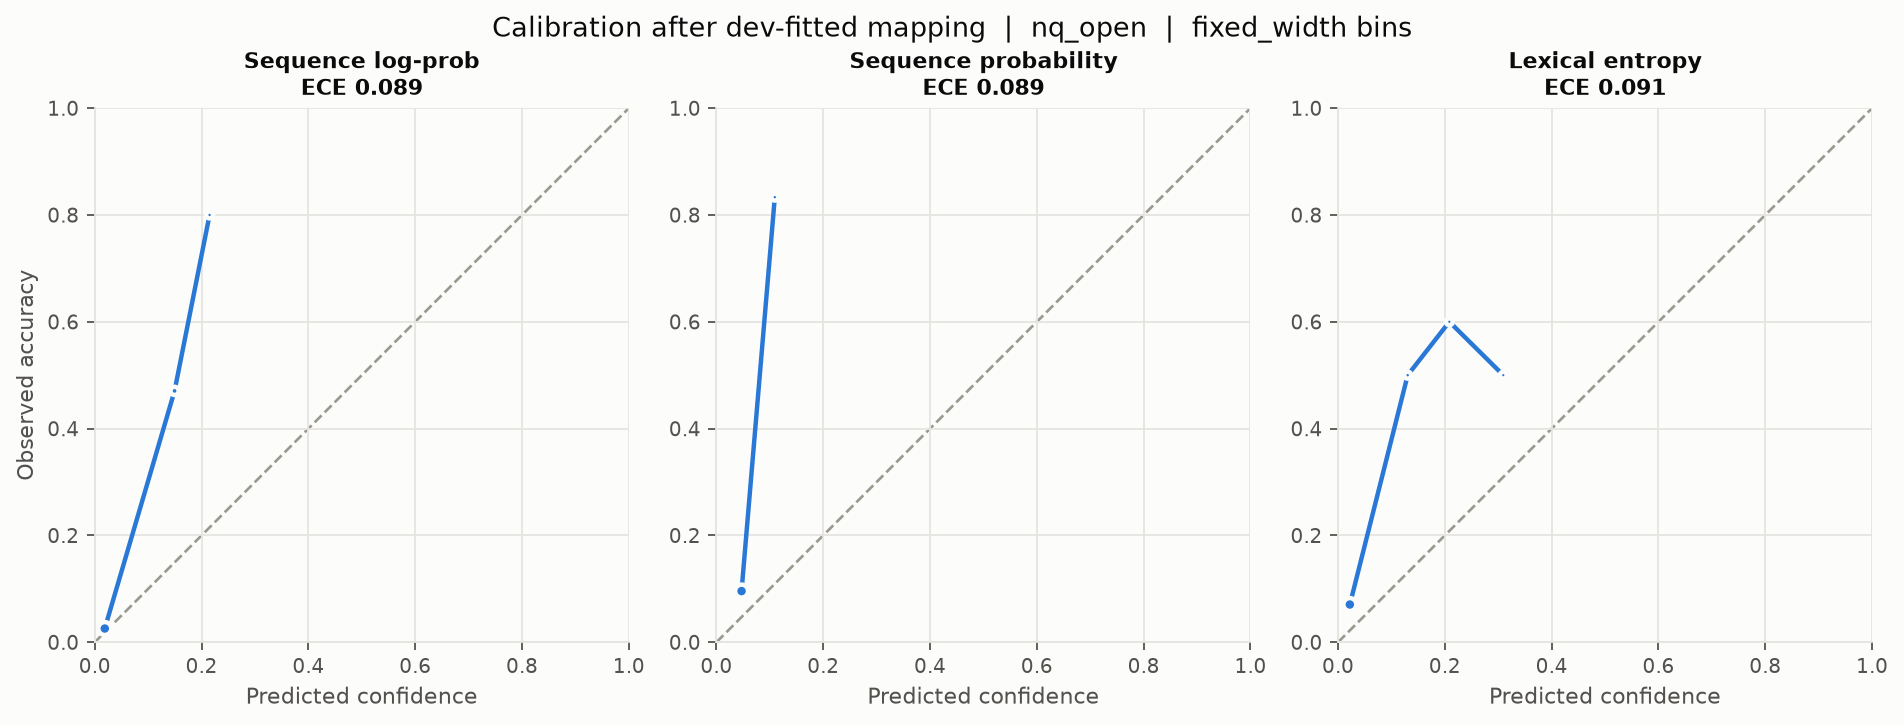

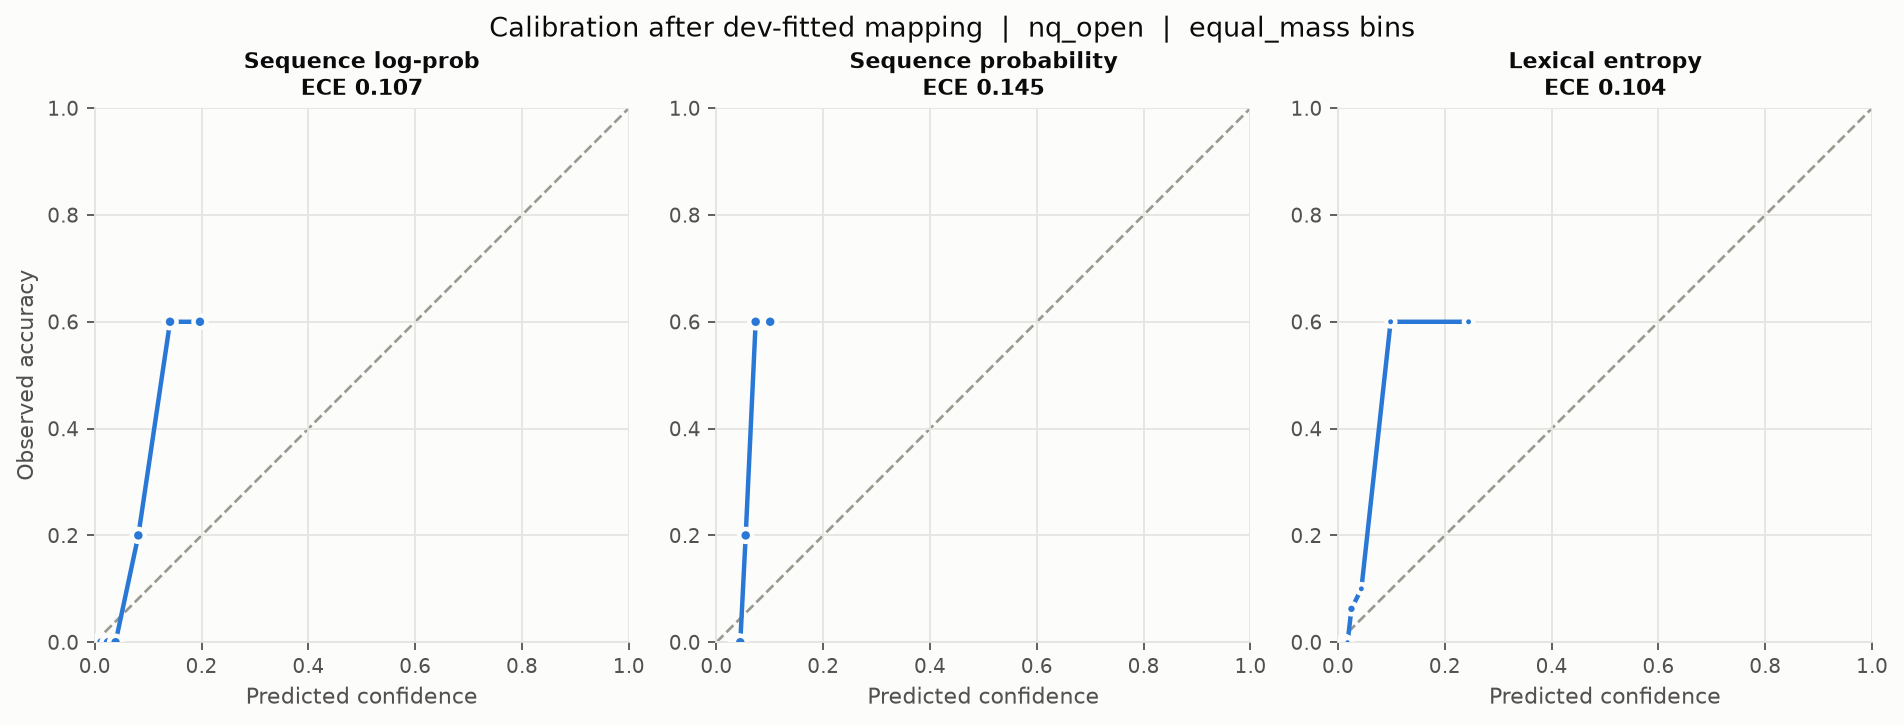

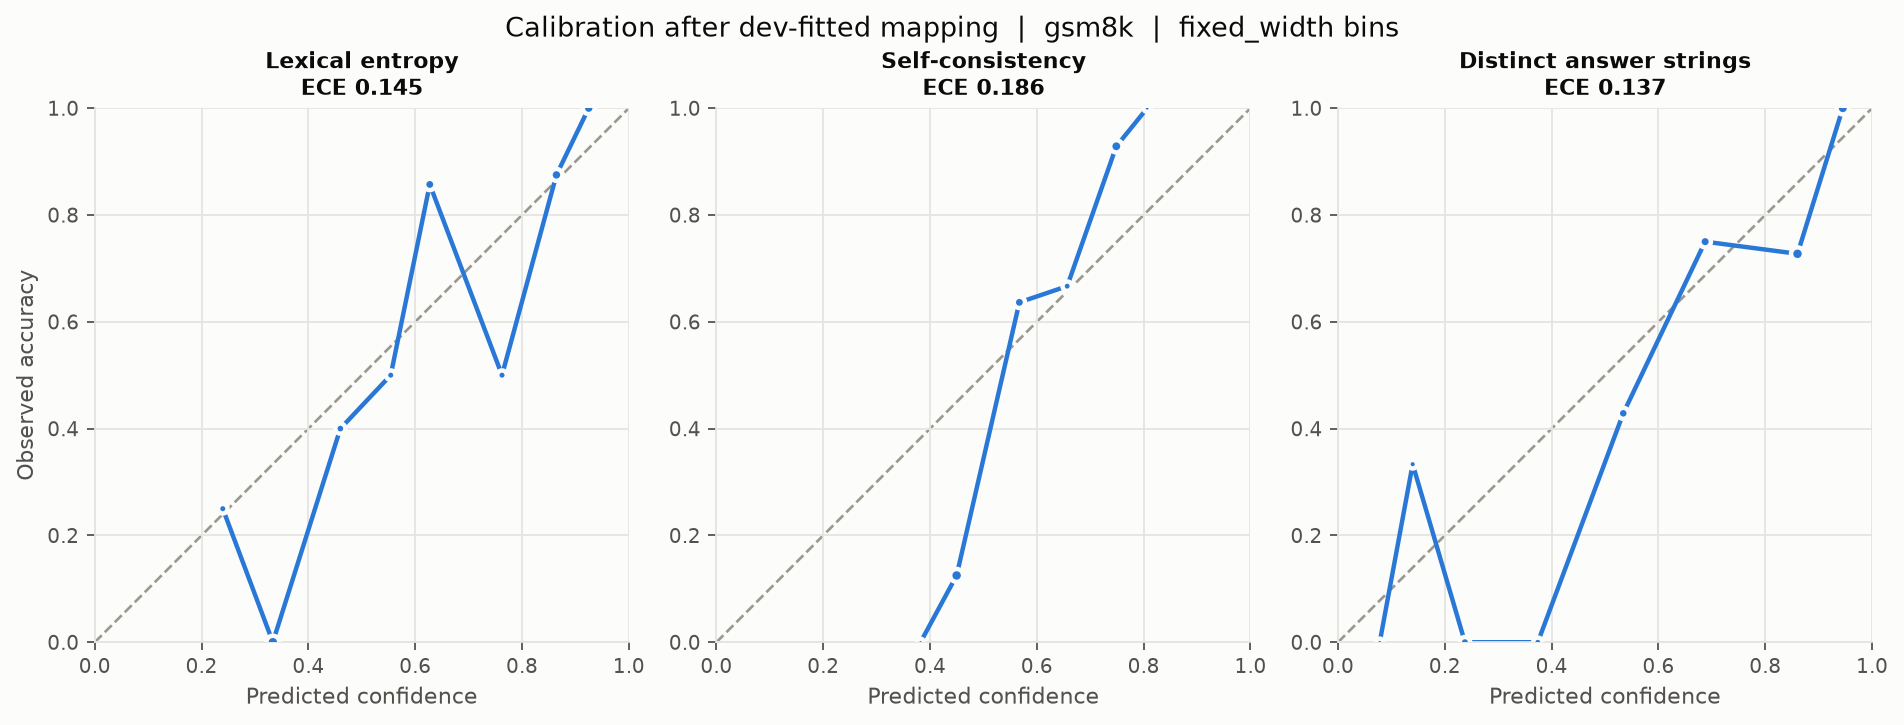

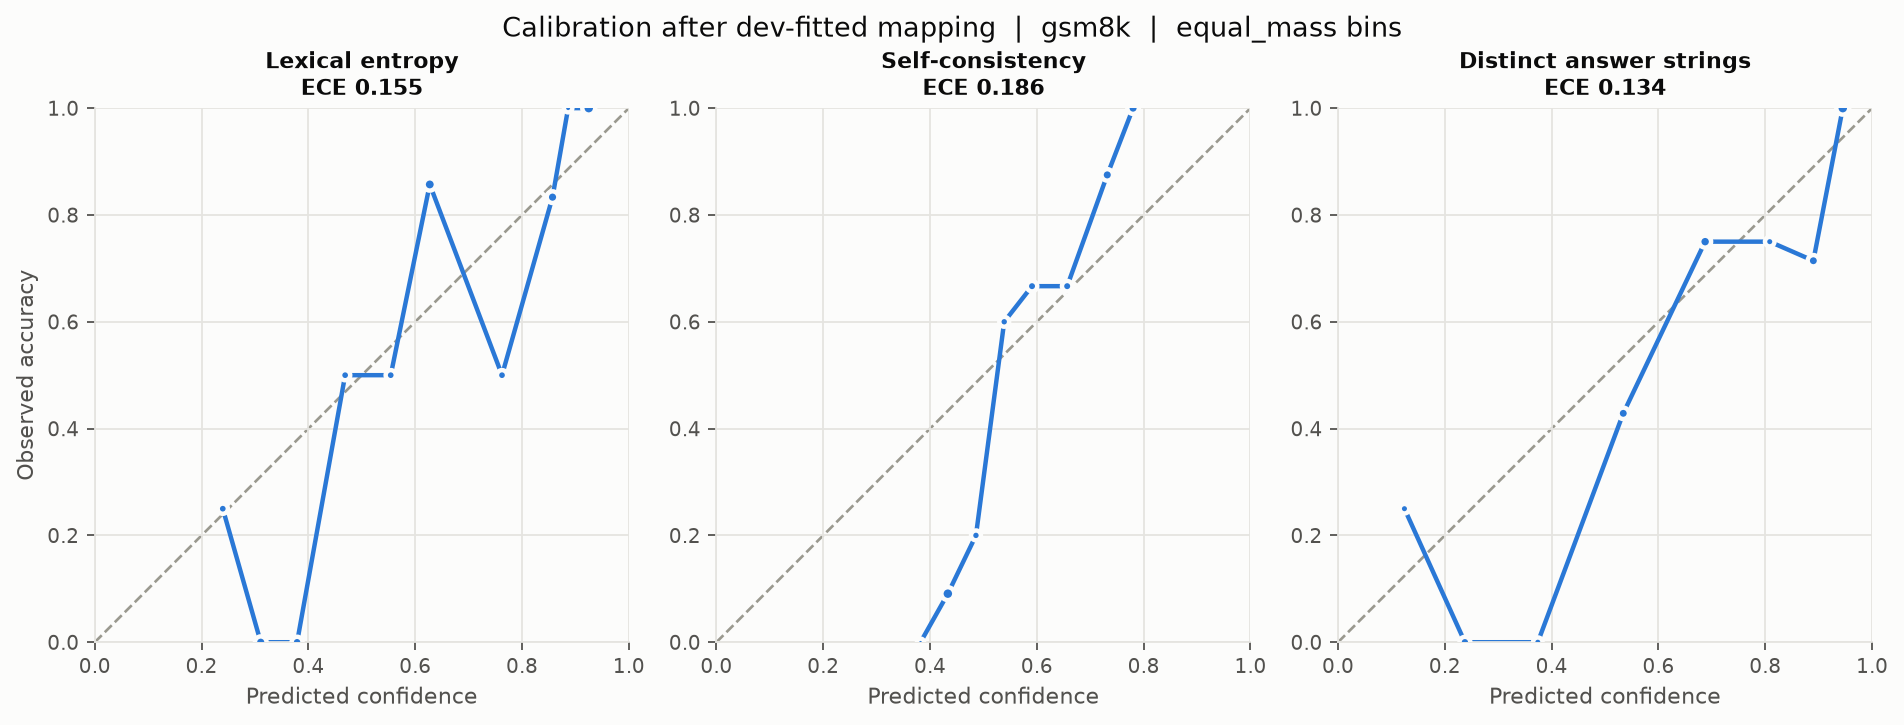

In [7]:
for task in TASKS:
    for strategy in ('fixed_width', 'equal_mass'):
        path = FIGURES_DIR / f'reliability_{strategy}_{task}.png'
        if path.exists():
            display(Image(filename=str(path)))

## 6. Applications

### Selective answering, confidence tags, and the cascade

In [8]:
for task, analysis in analyses.items():
    print(f'=== {task} | gating on {get_spec(analysis.best_signal).display_name} ===')
    display(pd.DataFrame([p.as_dict() for p in analysis.selective])[
        ['target_accuracy', 'test_coverage', 'test_accuracy', 'target_met_on_test']
    ])
    display(pd.DataFrame([t.as_dict() for t in analysis.tiers]))
    print()

=== nq_open | gating on Sequence log-prob ===


,target_accuracy,test_coverage,test_accuracy,target_met_on_test
0,0.25,0.10,0.600000,True
1,0.40,0.07,0.714286,True
2,0.50,0.00,NaN,False
3,0.60,0.00,NaN,False


,tier,count,share,accuracy
0,High,27,0.27,0.518519
1,Medium,36,0.36,0.000000
2,Low,37,0.37,0.000000



=== gsm8k | gating on Lexical entropy ===


,target_accuracy,test_coverage,test_accuracy,target_met_on_test
0,0.6,1.00,0.560000,False
1,0.7,0.74,0.729730,True
2,0.8,0.70,0.771429,False
3,0.9,0.44,0.863636,False


,tier,count,share,accuracy
0,High,19,0.38,0.842105
1,Medium,16,0.32,0.687500
2,Low,15,0.30,0.066667


In [9]:
cascade = analyses['gsm8k'].cascade
if cascade is not None:
    print(f'Greedy only:              {cascade.greedy_accuracy:.3f}  (1.00 generations)')
    print(f'Self-consistency always:  {cascade.self_consistency_accuracy:.3f}  '
          f'({1 + cascade.num_samples:.2f} generations)')
    if cascade.selected:
        s = cascade.selected
        print(f'Uncertainty-gated:        {s.test_accuracy:.3f}  '
              f'({s.mean_generations:.2f} generations, '
              f'{s.test_escalation_rate:.0%} escalated)')
    display(pd.DataFrame([p.as_dict() for p in cascade.curve]))

Greedy only:              0.560  (1.00 generations)
Self-consistency always:  0.660  (11.00 generations)
Uncertainty-gated:        0.640  (7.80 generations, 68% escalated)


,escalation_budget,threshold,test_escalation_rate,test_accuracy,mean_generations,generation_cost_ratio
0,0.0,inf,0.00,0.56,1.0,0.090909
1,0.1,2.163956,0.02,0.56,1.2,0.109091
2,0.2,1.862098,0.26,0.62,3.6,0.327273
3,0.3,1.748067,0.30,0.62,4.0,0.363636
4,0.4,1.597947,0.38,0.62,4.8,0.436364
5,0.5,1.227529,0.56,0.62,6.6,0.600000
6,0.6,1.136529,0.60,0.62,7.0,0.636364
7,0.8,0.639032,0.68,0.64,7.8,0.709091
8,1.0,-inf,1.00,0.66,11.0,1.000000


## 7. All figures

auroc_by_signal_gsm8k.png


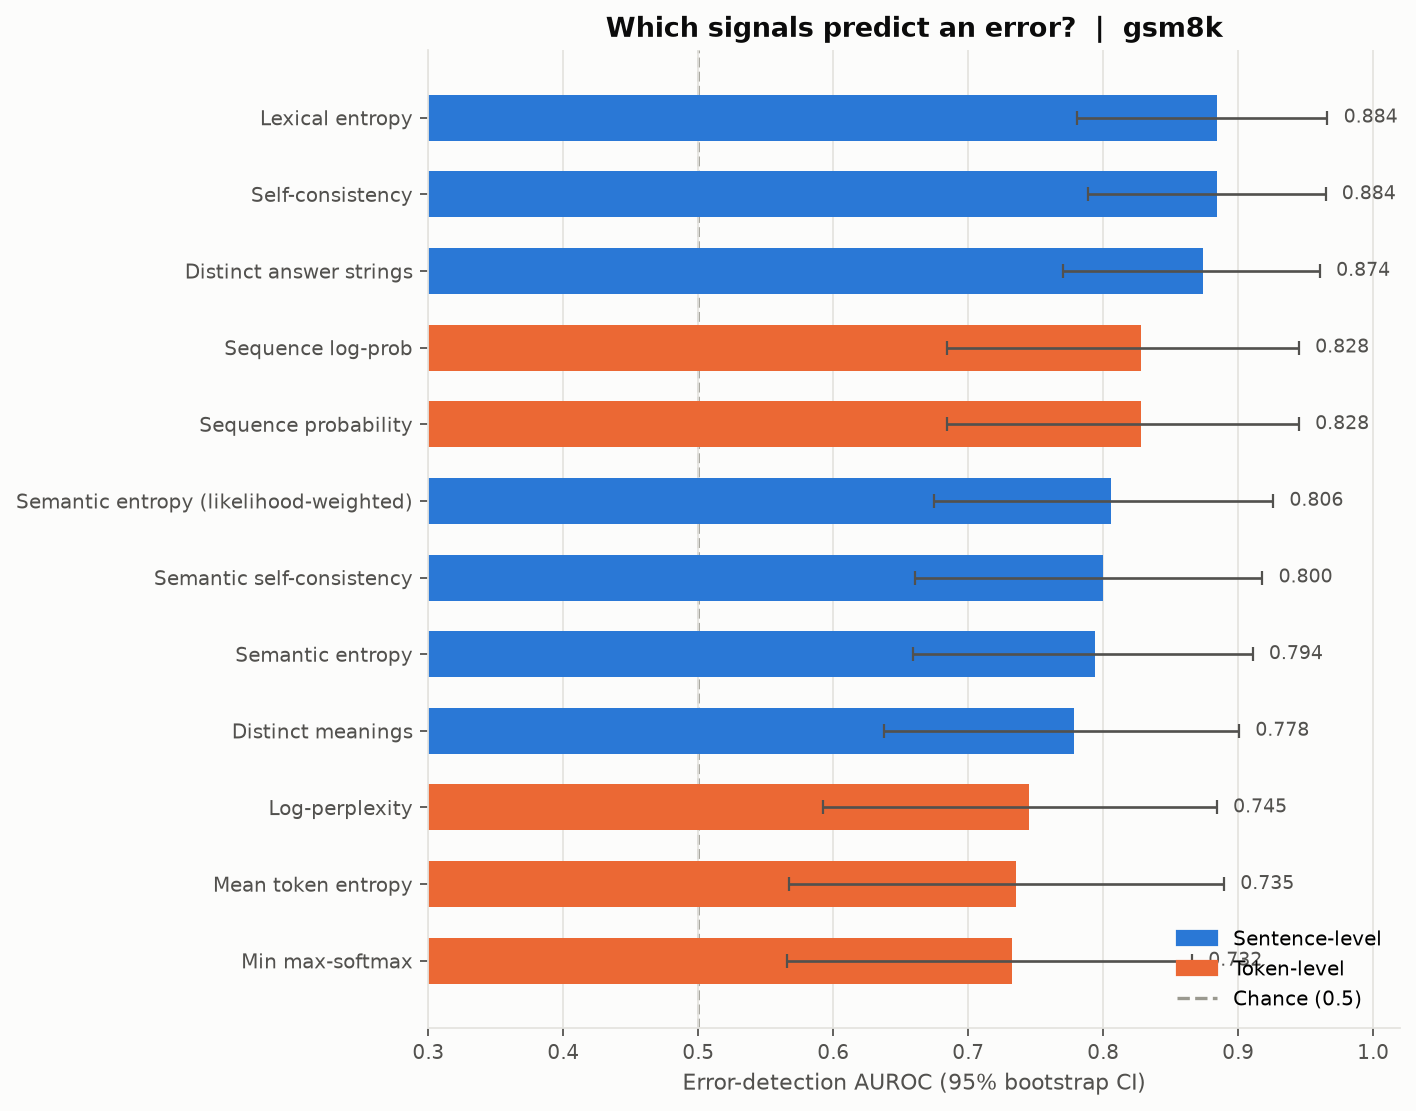

auroc_by_signal_nq_open.png


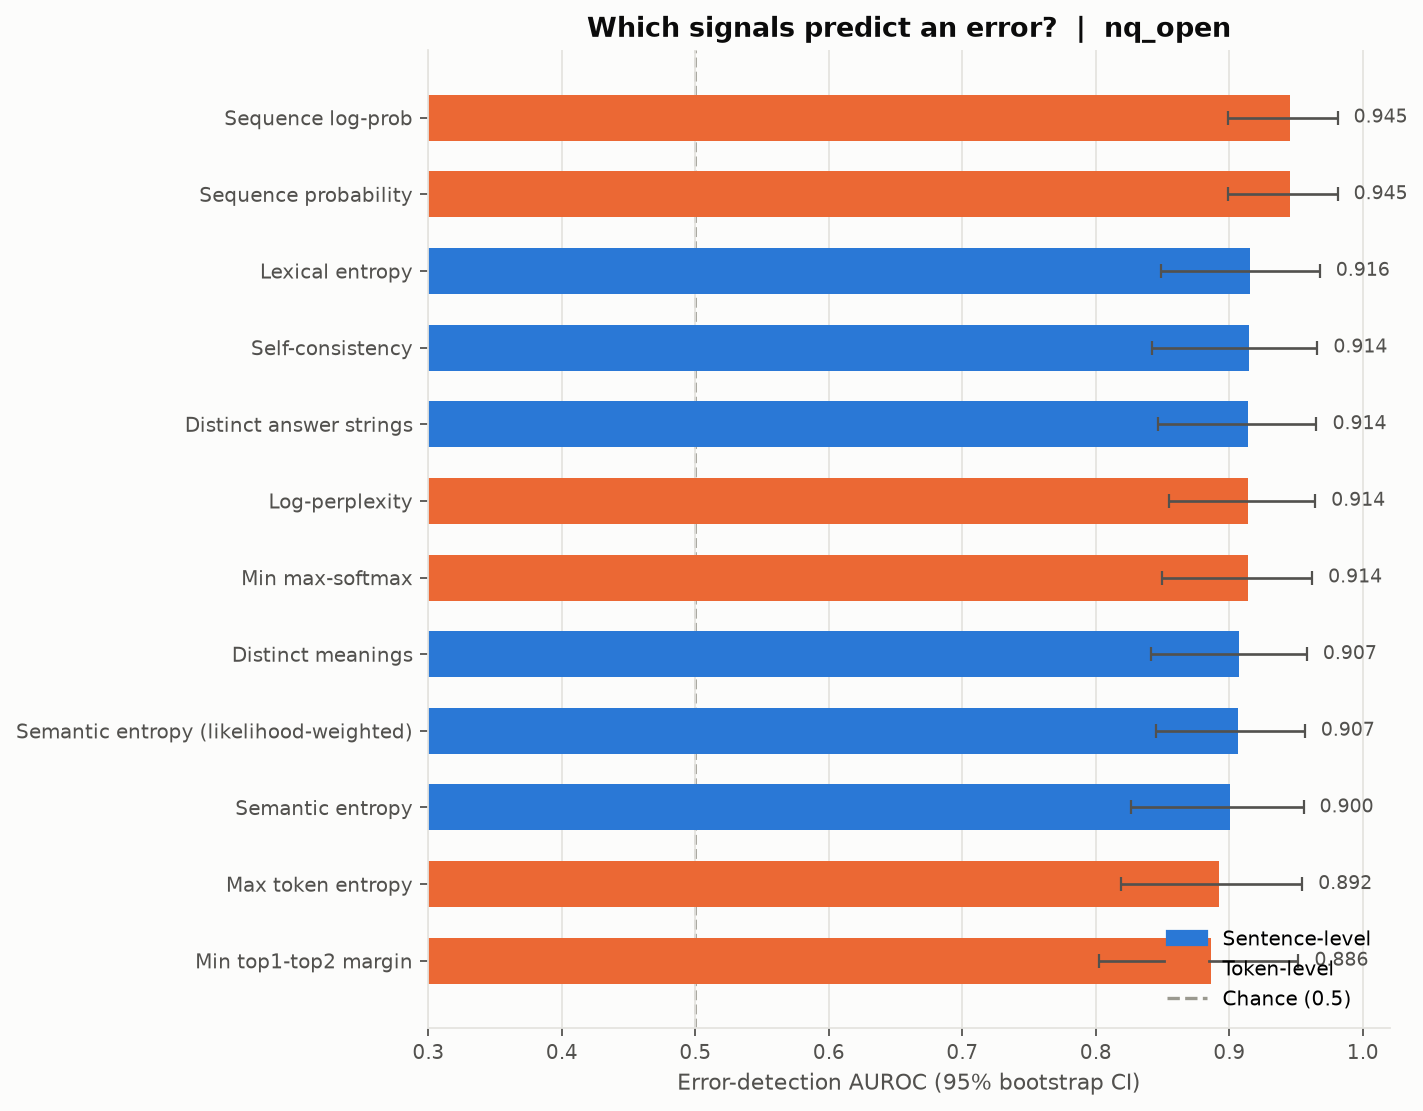

cascade_gsm8k.png


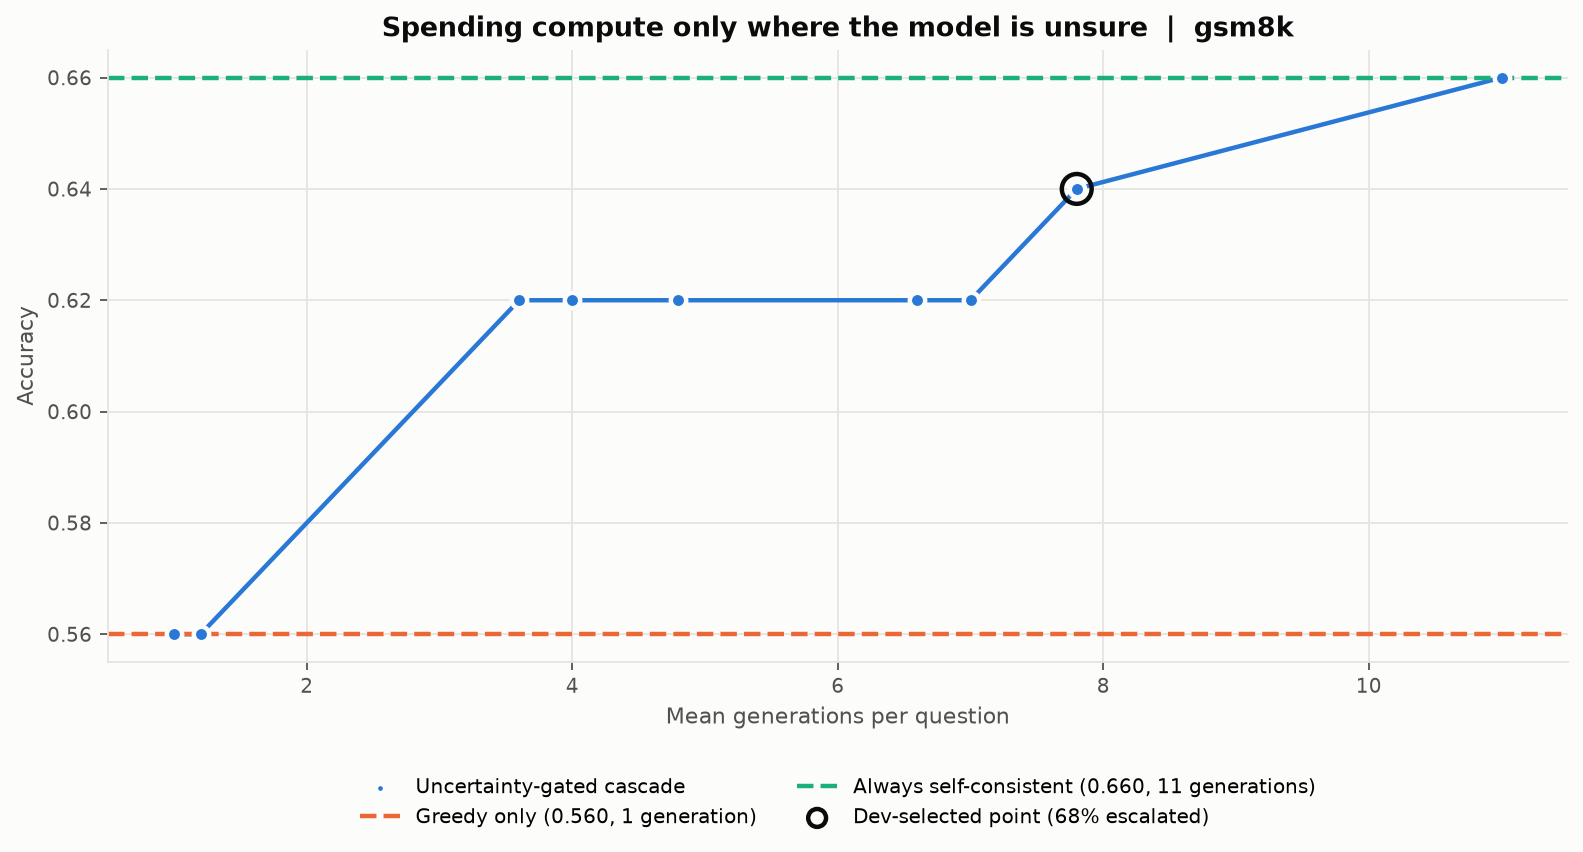

confidence_tiers_gsm8k.png


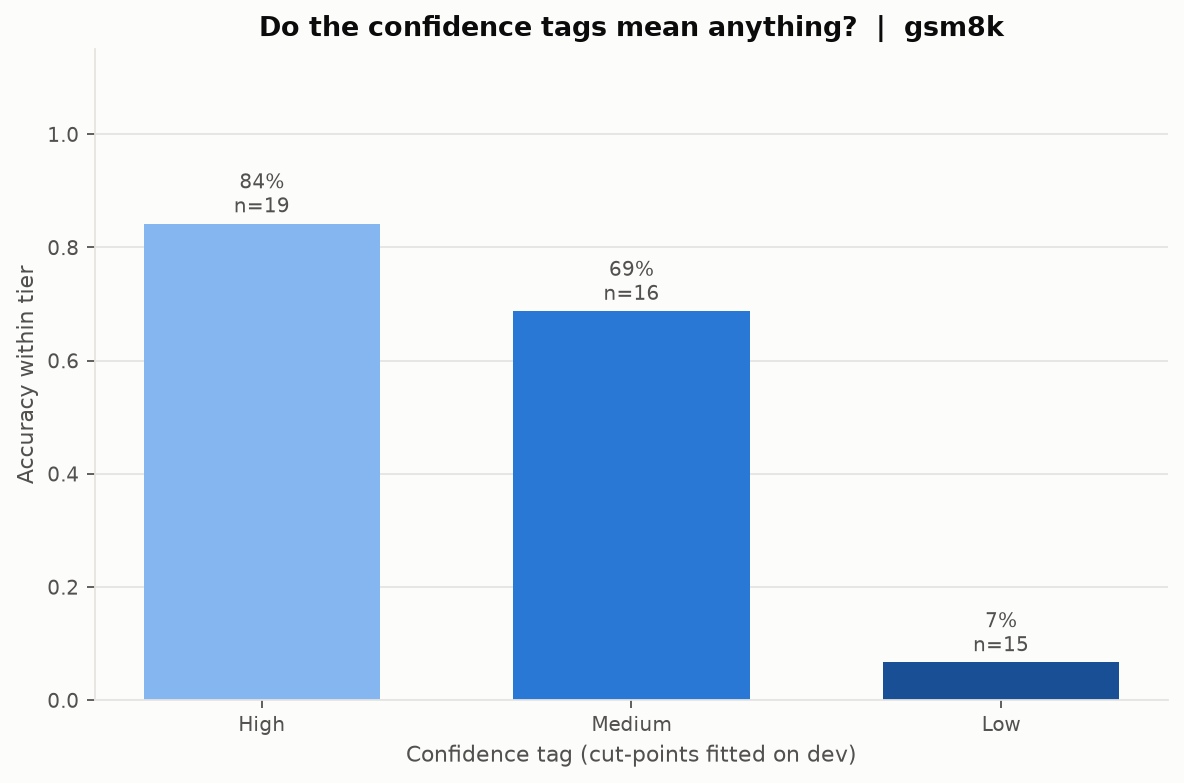

confidence_tiers_nq_open.png


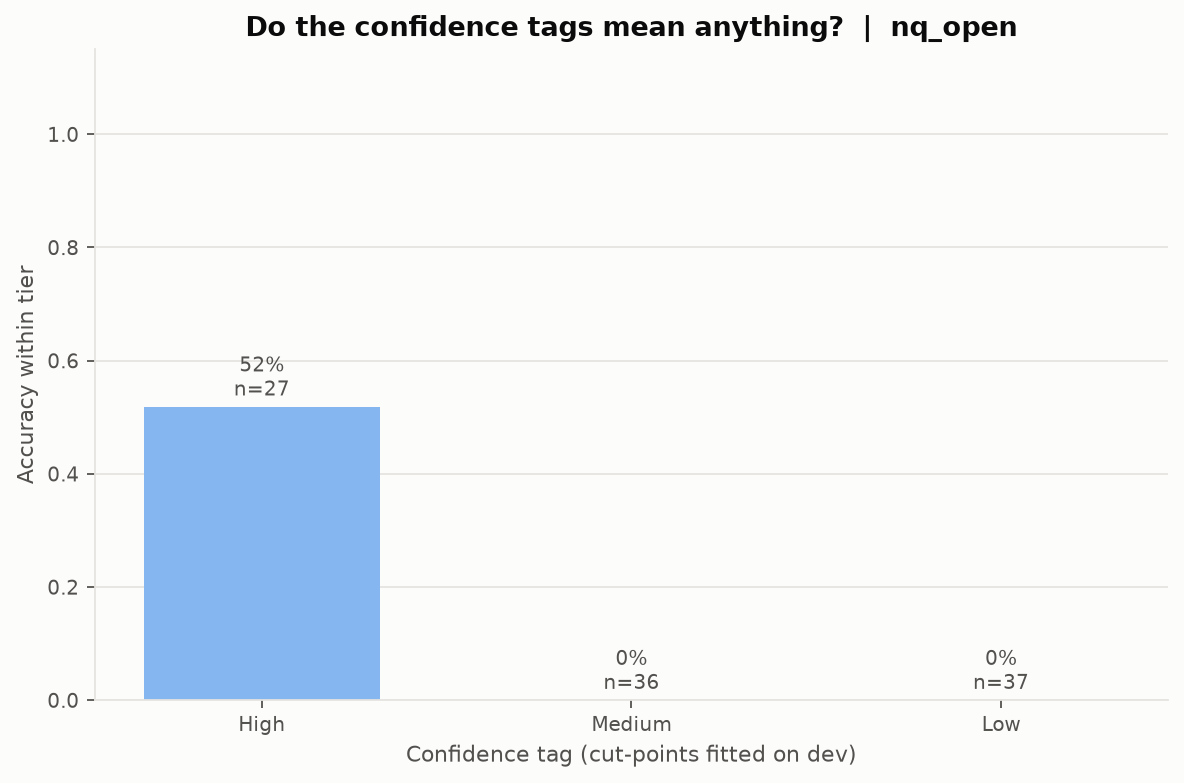

cost_quality_gsm8k.png


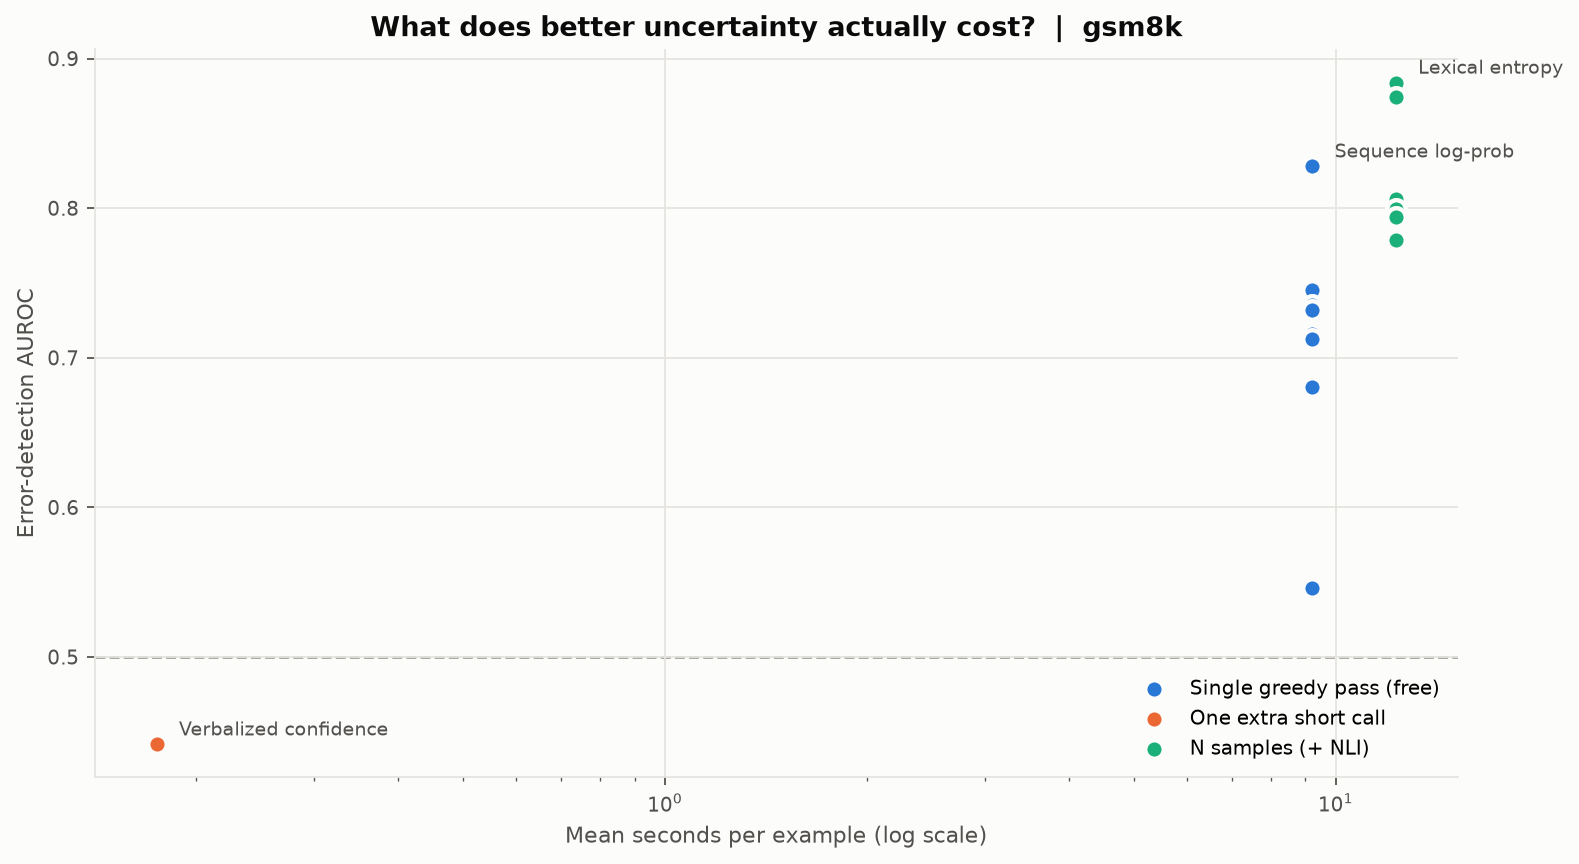

cost_quality_nq_open.png


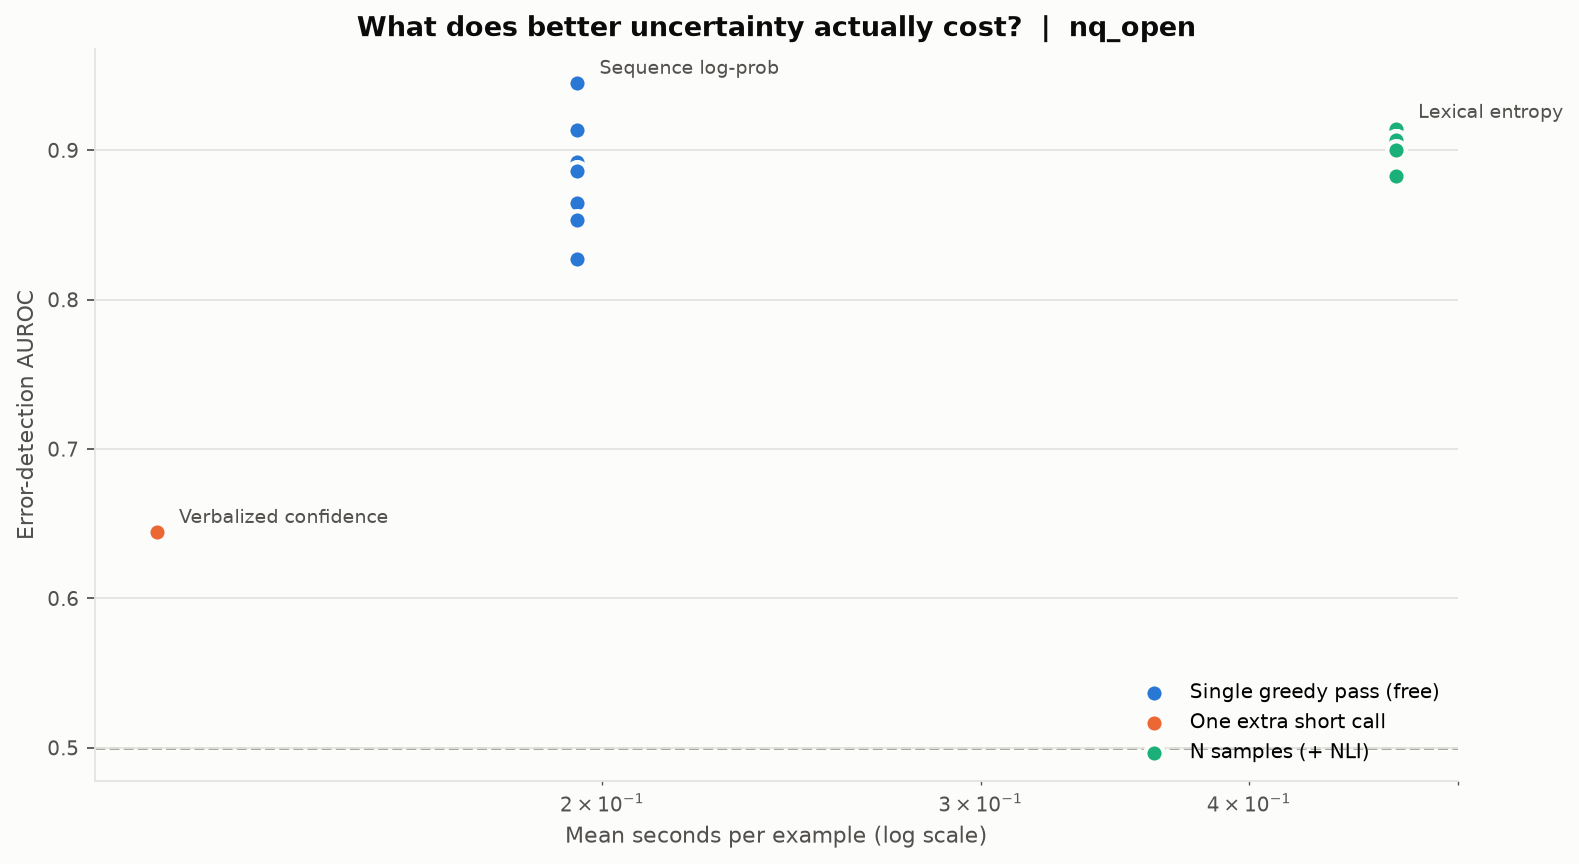

distribution_gsm8k.png


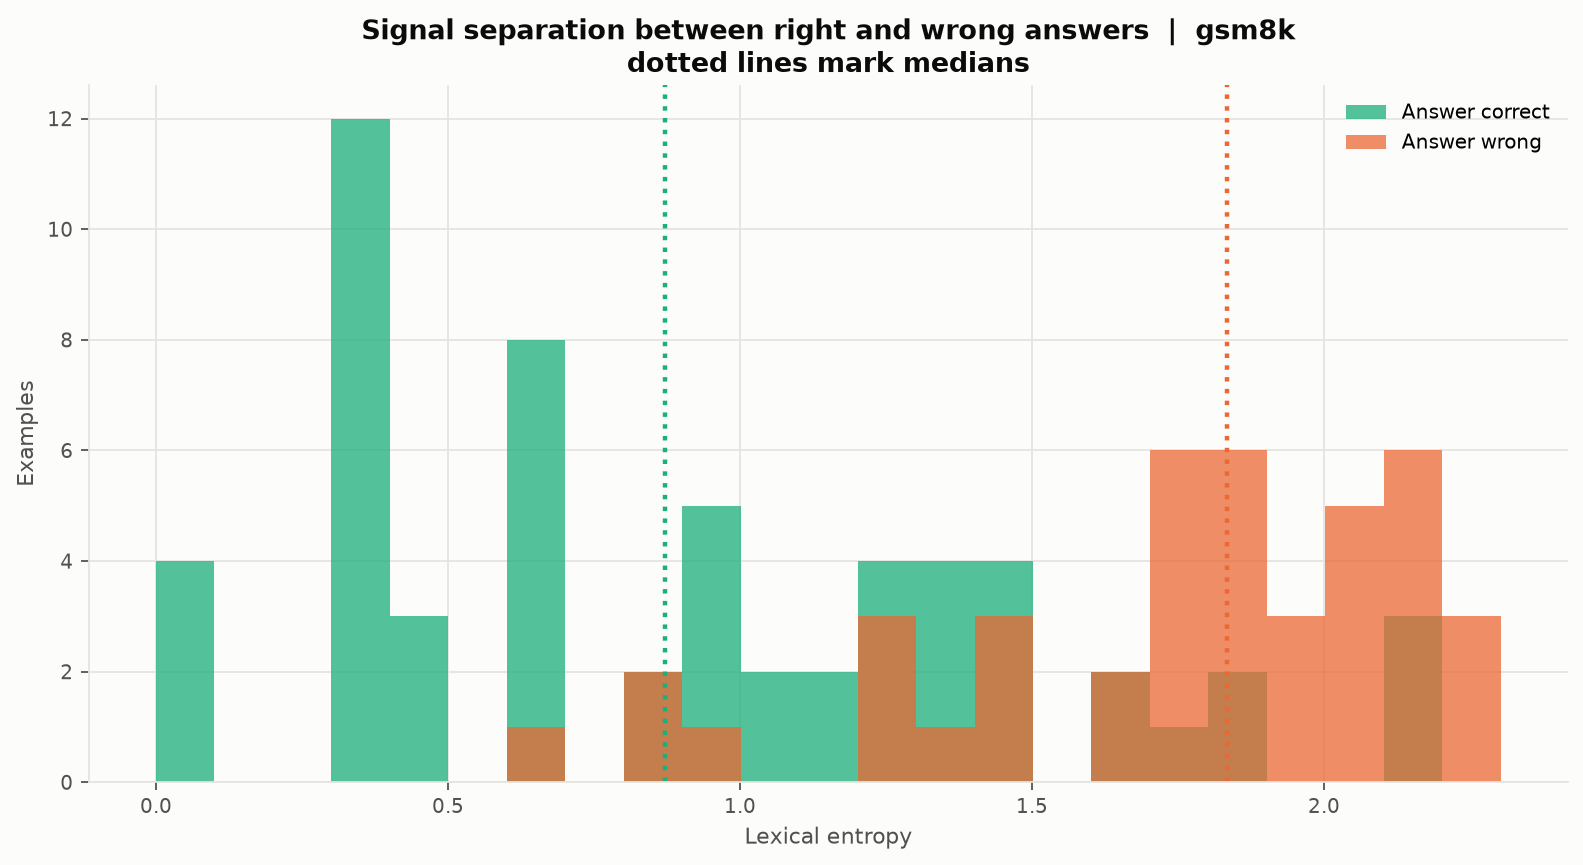

distribution_nq_open.png


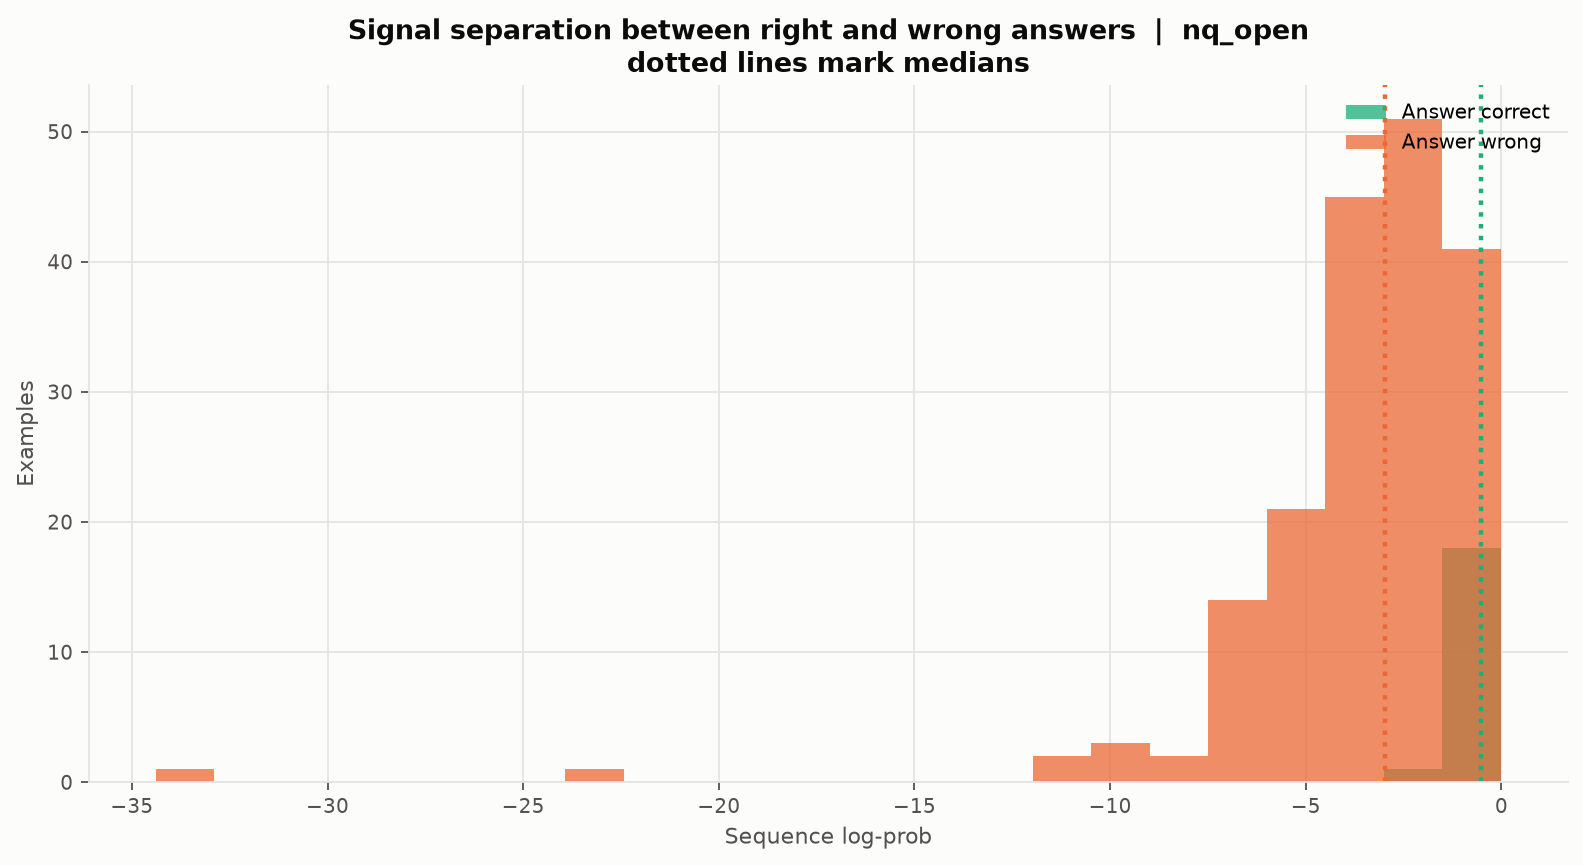

reliability_equal_mass_gsm8k.png


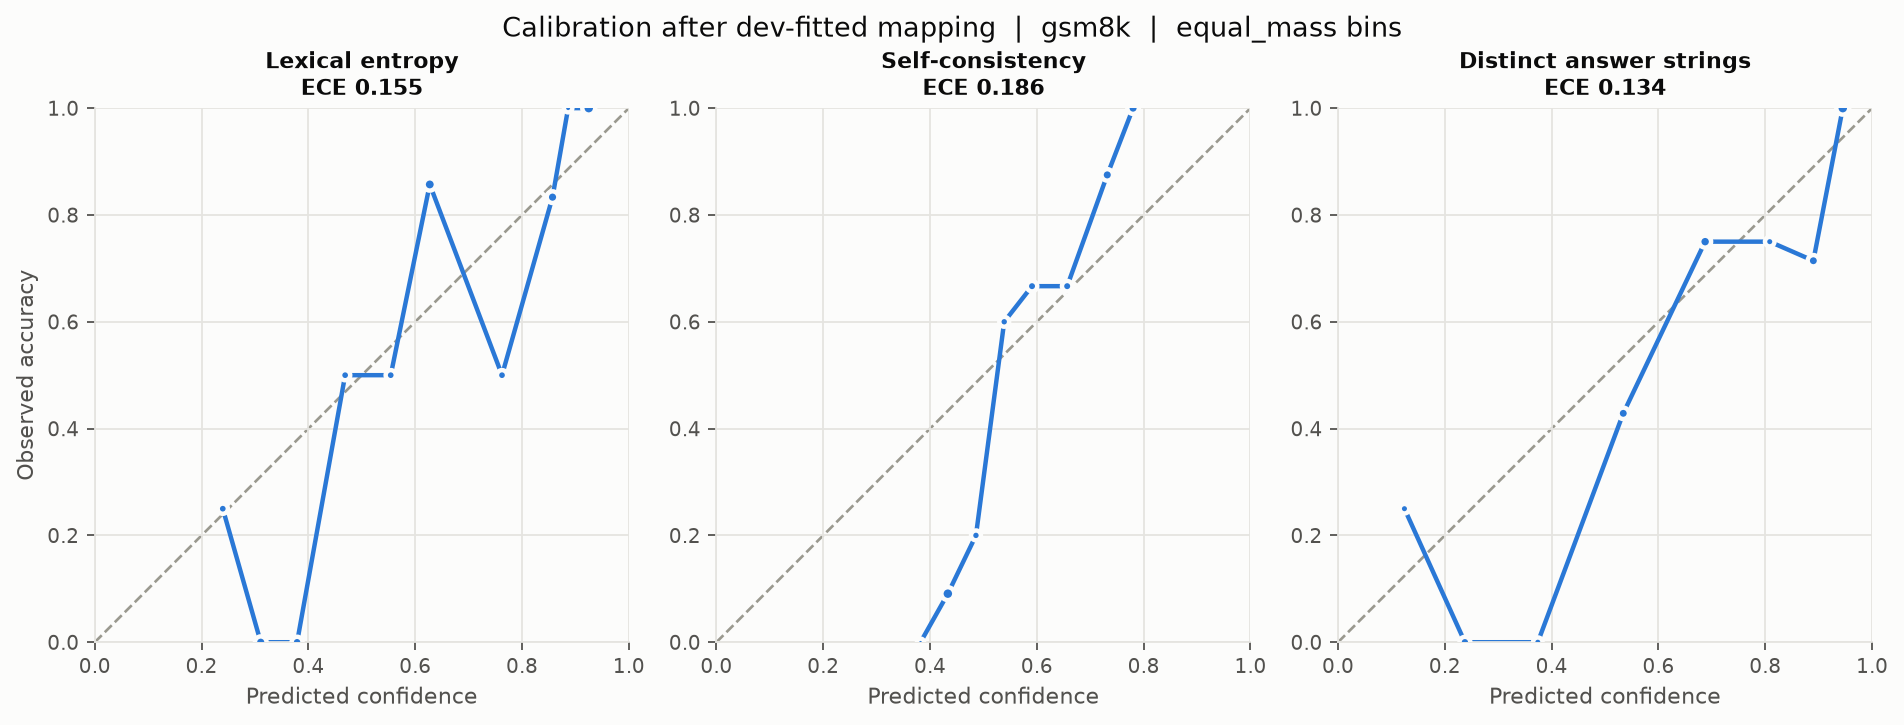

reliability_equal_mass_nq_open.png


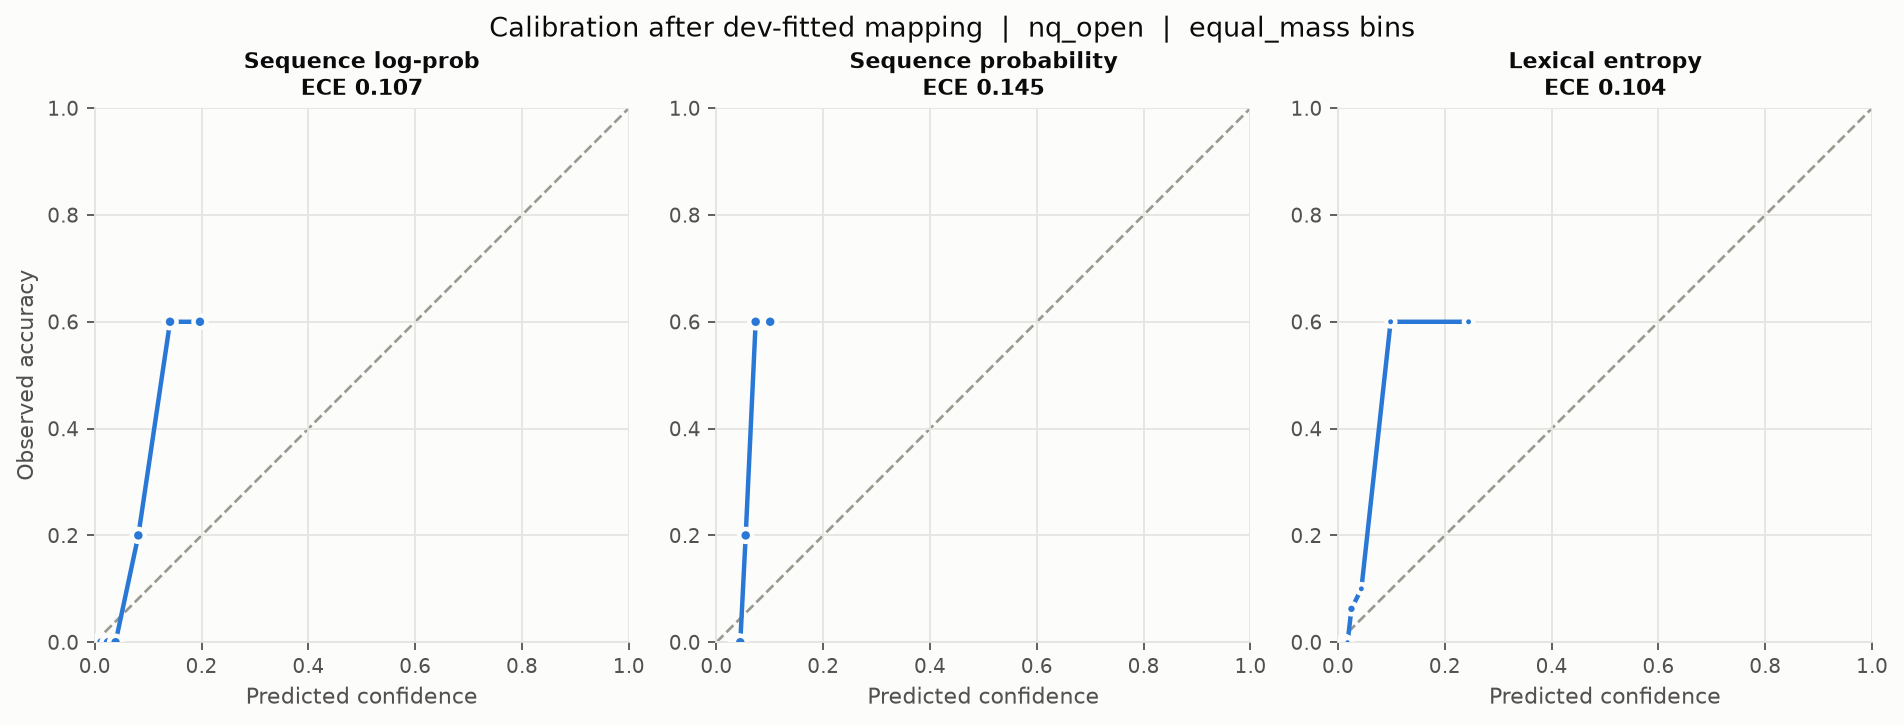

reliability_fixed_width_gsm8k.png


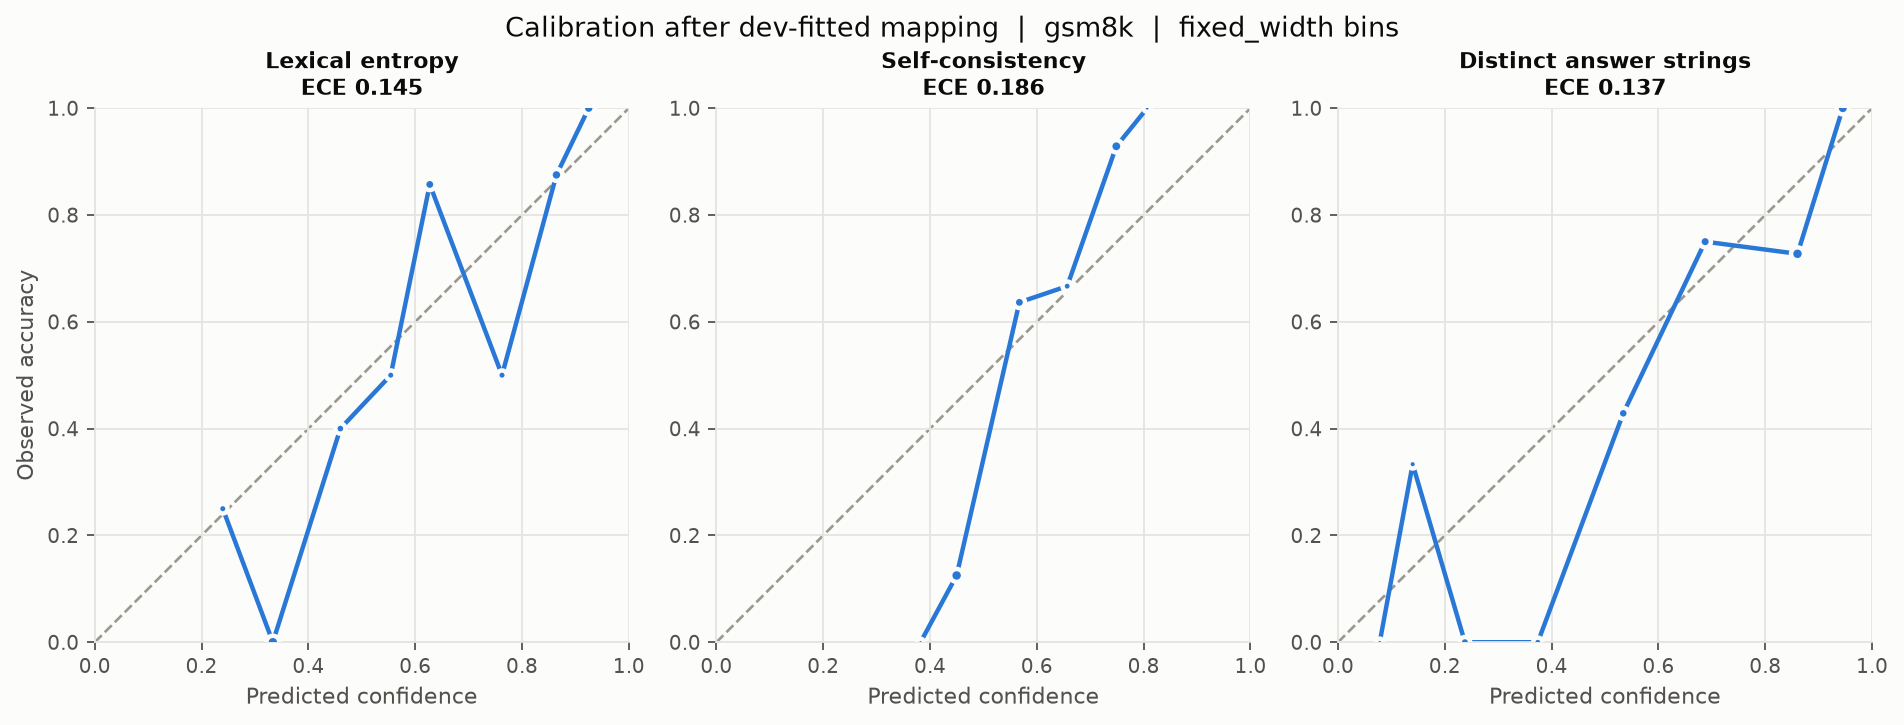

reliability_fixed_width_nq_open.png


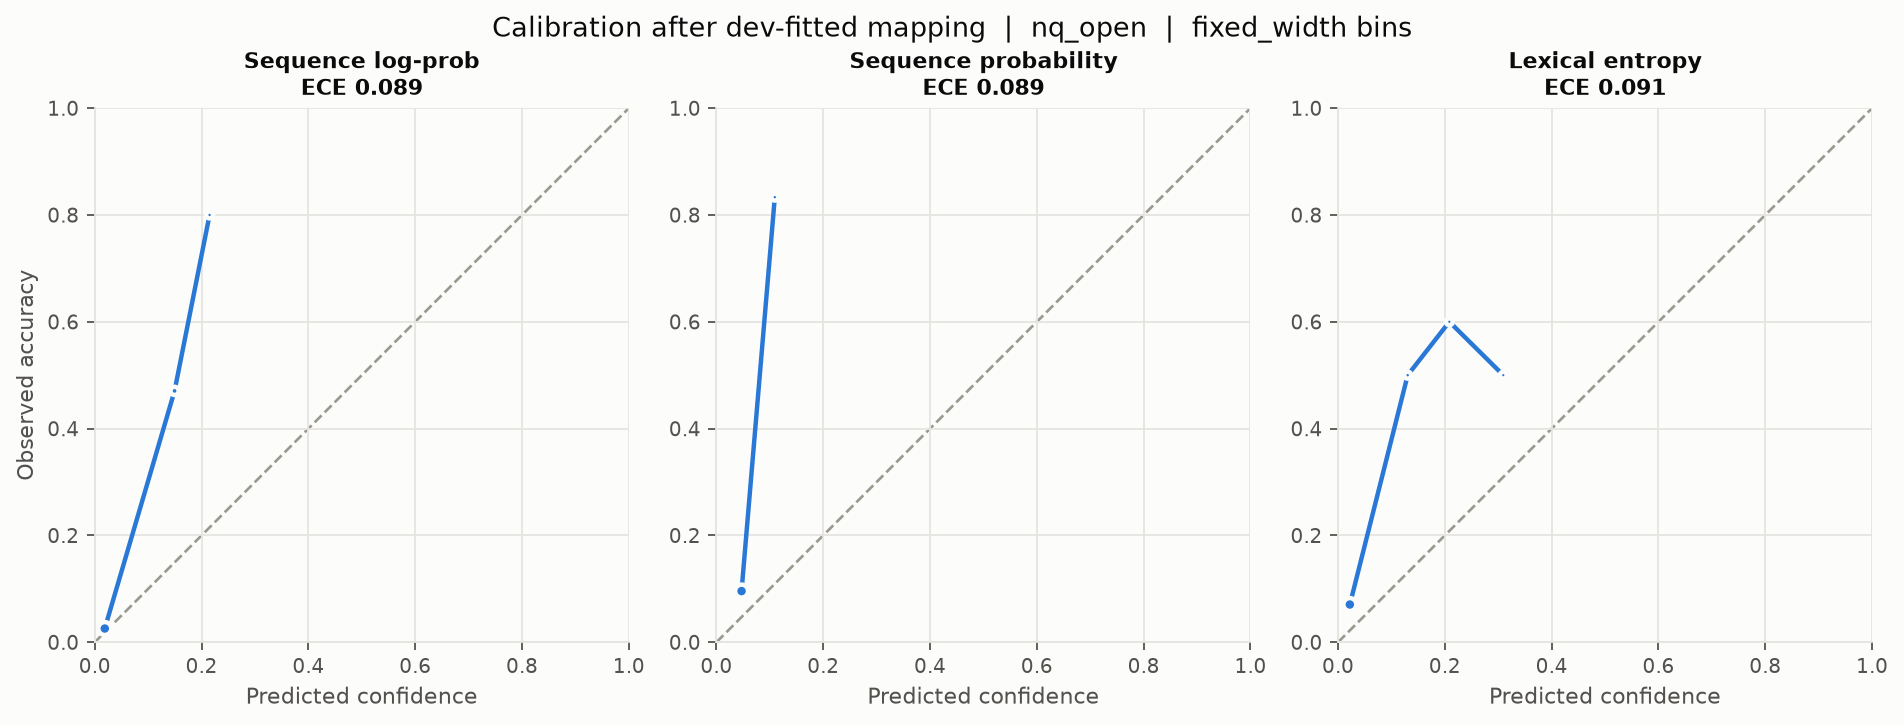

risk_coverage_gsm8k.png


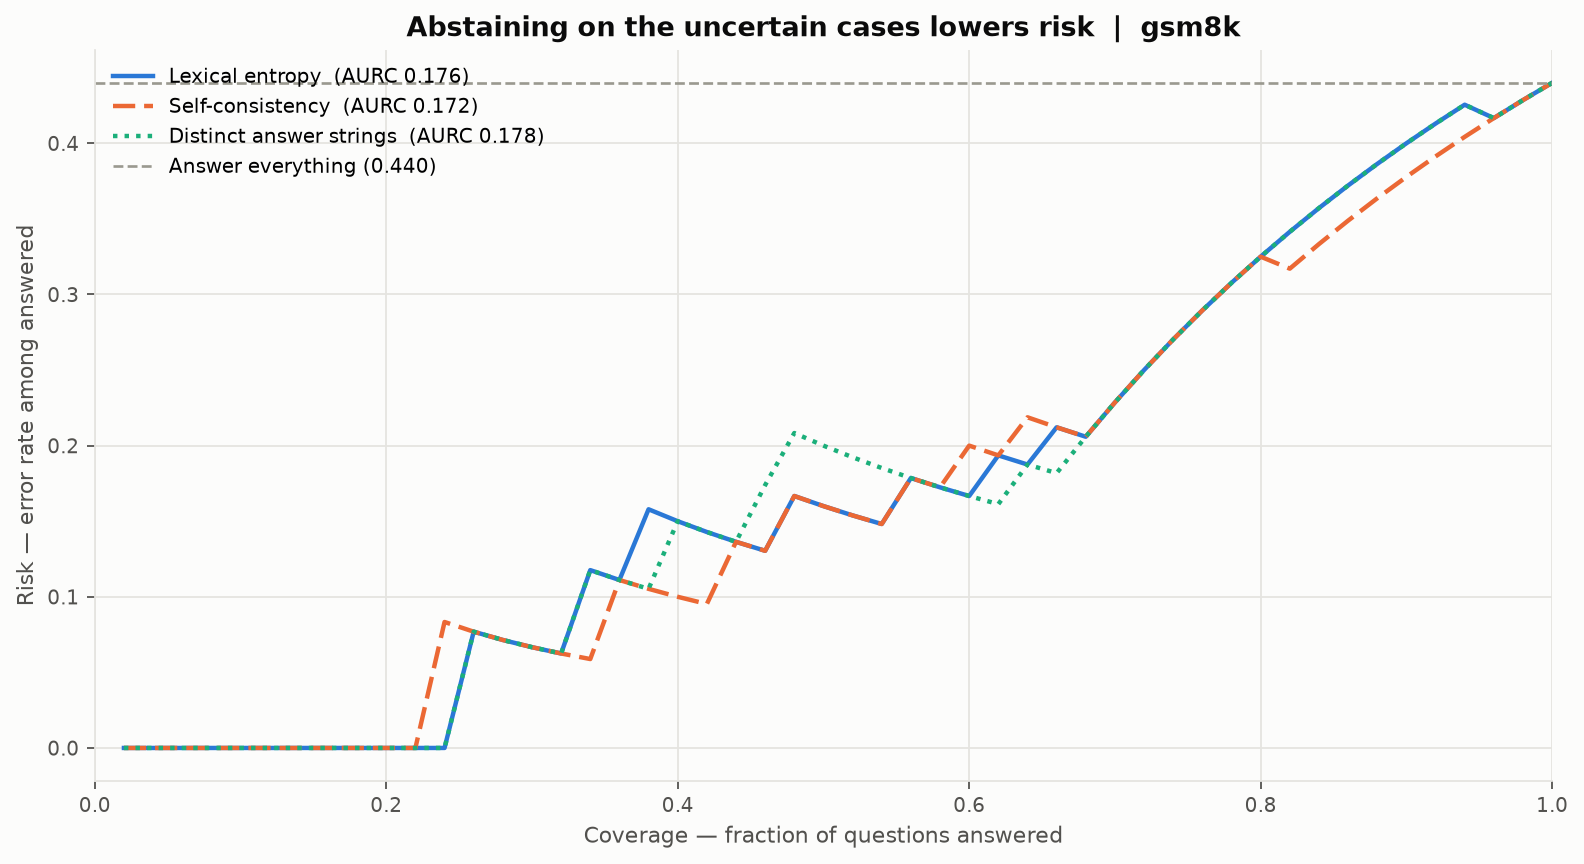

risk_coverage_nq_open.png


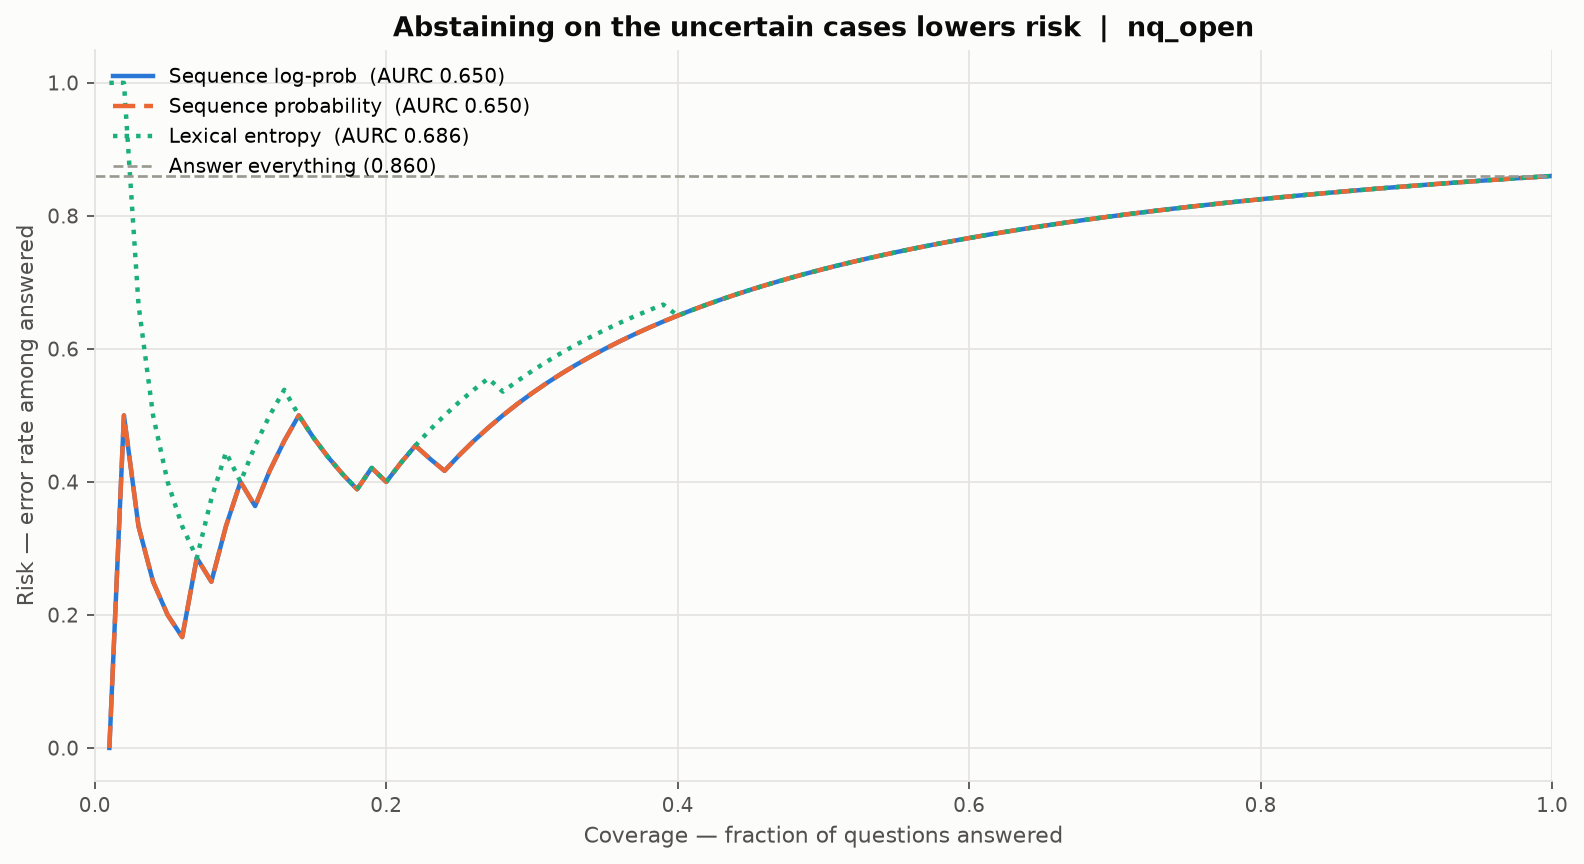

selective_answering_gsm8k.png


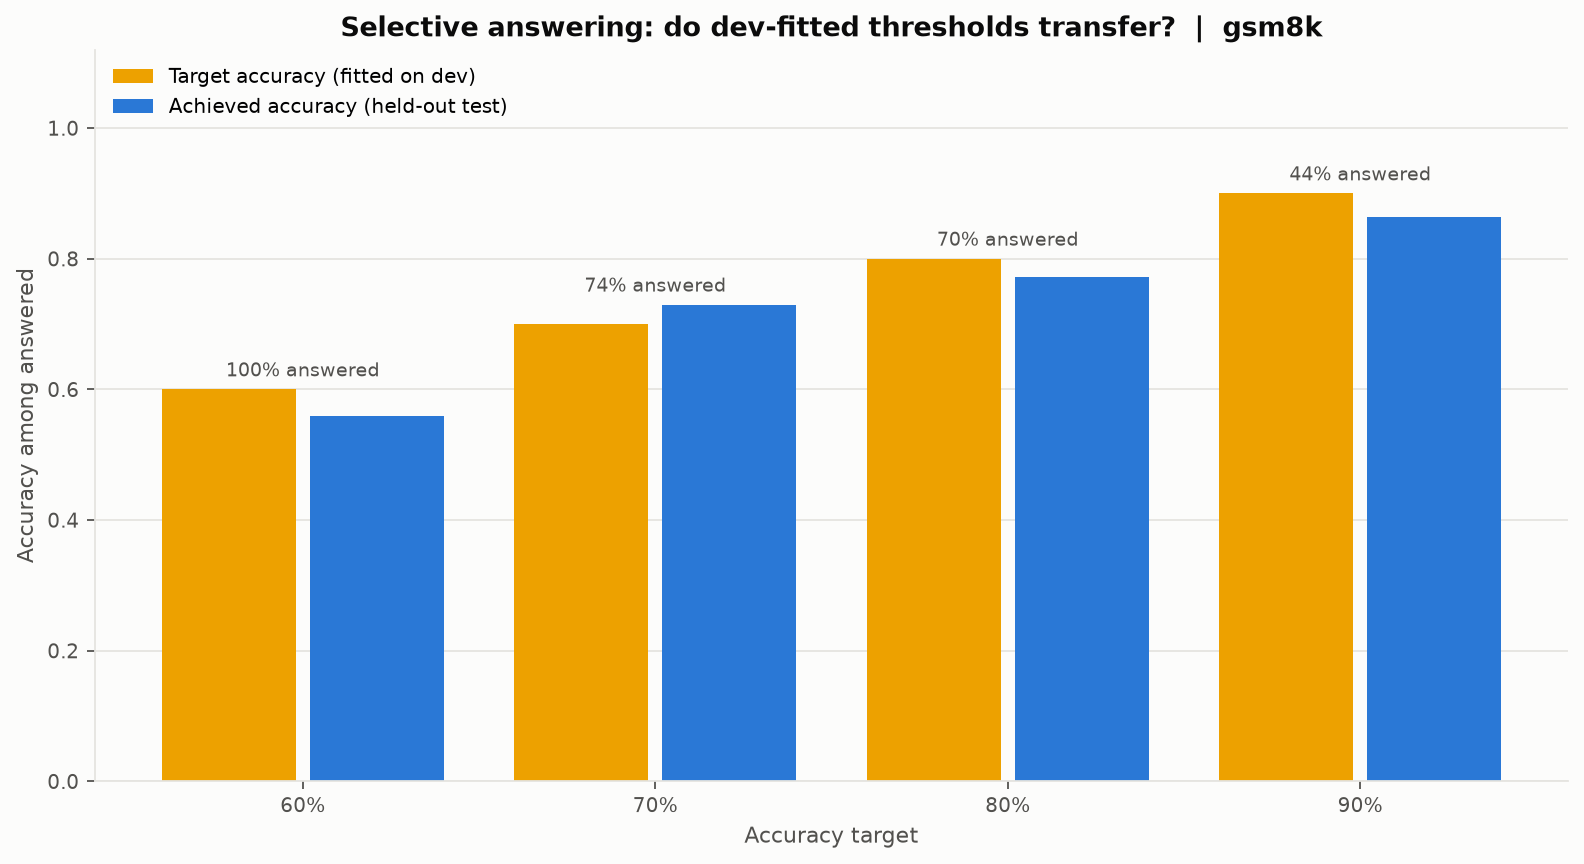

selective_answering_nq_open.png


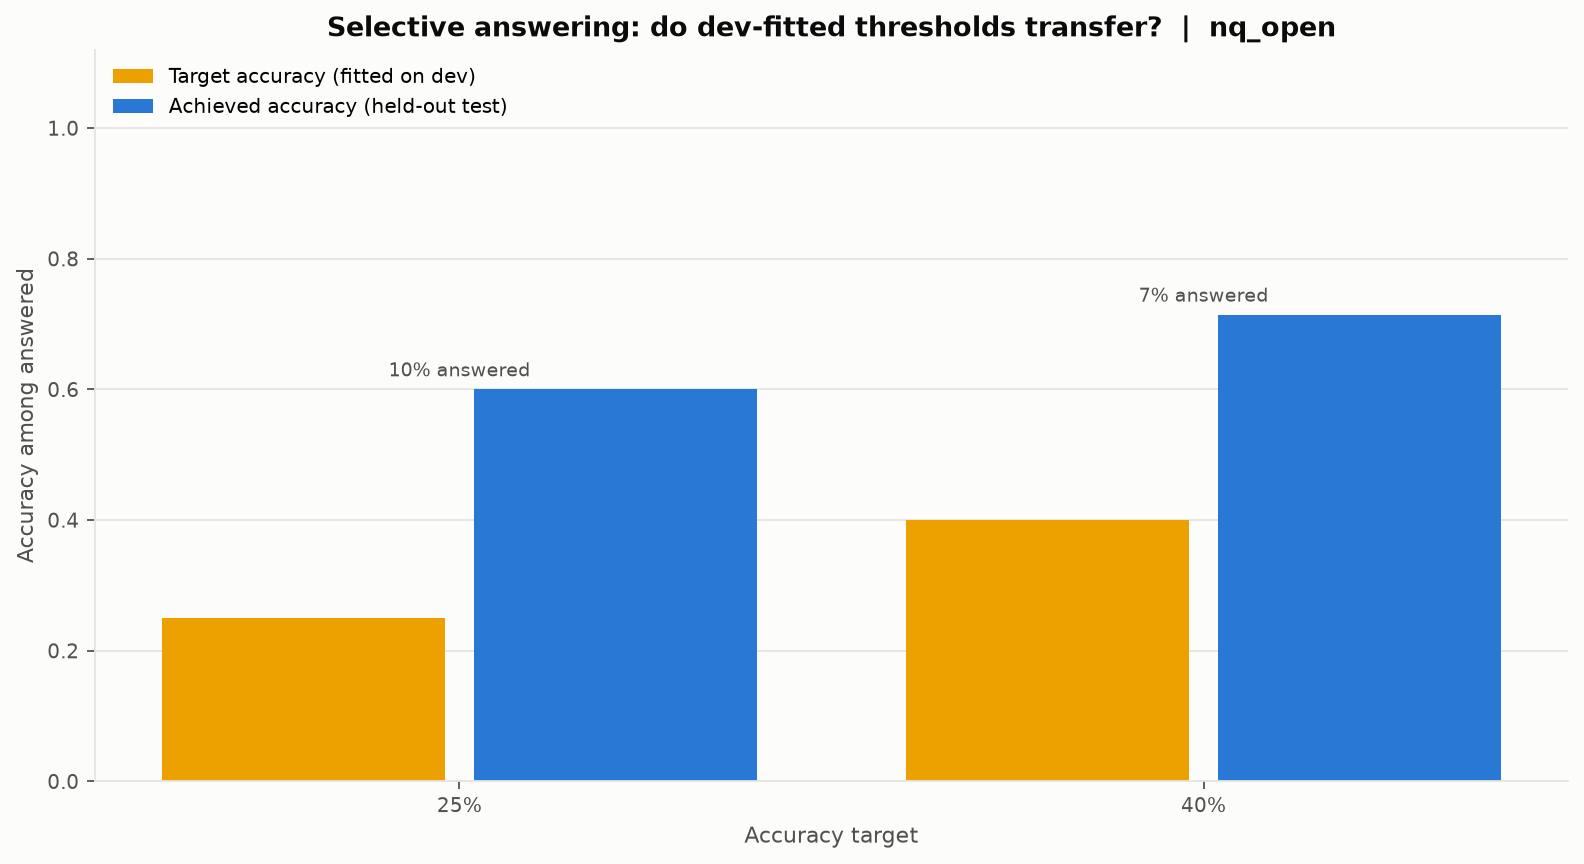

In [10]:
for path in sorted(FIGURES_DIR.glob('*.png')):
    print(path.name)
    display(Image(filename=str(path)))